In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.cluster import KMeans
from kneed import KneeLocator
# for automatic elbow detectionimport warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="joblib")


In [11]:
iris = datasets.load_iris()
samples = iris.data
target = iris.target

# Step 1: Fit KMeans with 3 clusters
model = KMeans(n_clusters=3, random_state=42)   
model.fit(samples)

# Step 2: Predict labels
labels = model.predict(samples)
print("Cluster labels for iris dataset:\n", labels)

# Step 3: Predict new samples
new_samples = np.array([
    [5.7, 4.4, 1.5, 0.4],
    [6.5, 3.0, 5.5, 0.4],
    [5.8, 2.7, 5.1, 1.9]
])
print("New samples:\n", new_samples)
new_labels = model.predict(new_samples)
print("Predicted cluster labels for new samples:\n", new_labels)

Cluster labels for iris dataset:
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]
New samples:
 [[5.7 4.4 1.5 0.4]
 [6.5 3.  5.5 0.4]
 [5.8 2.7 5.1 1.9]]
Predicted cluster labels for new samples:
 [1 2 2]


Predicted species names:
 [np.str_('versicolor'), np.str_('virginica'), np.str_('virginica')]


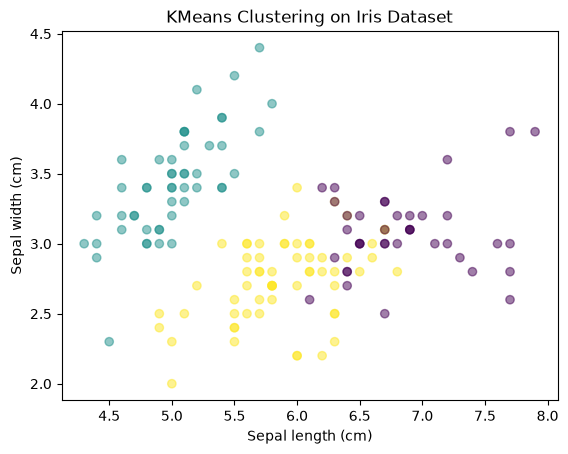

In [12]:
# Step 4: Map predicted labels to species names
new_names = [iris.target_names[label] for label in new_labels]
print("Predicted species names:\n", new_names)

# Step 5: Scatter plot of sepal length vs sepal width
x = samples[:, 0]
y = samples[:, 1]
plt.scatter(x, y, c=labels, alpha=0.5)
plt.xlabel('Sepal length (cm)')
plt.ylabel('Sepal width (cm)')
plt.title('KMeans Clustering on Iris Dataset')
plt.show()

Cluster vs Species Crosstab:
 species  setosa  versicolor  virginica
labels                                
0             0           3         36
1            50           0          0
2             0          47         14


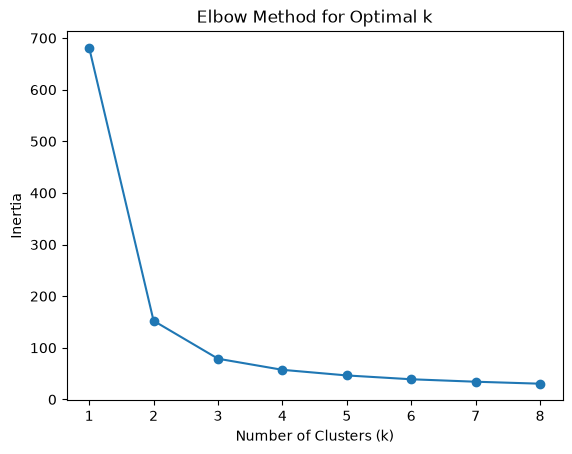

In [13]:
# Step 6: Crosstab of predicted clusters vs true species
species = [iris.target_names[t] for t in target]
df = pd.DataFrame({'labels': labels, 'species': species})
ct = pd.crosstab(df['labels'], df['species'])
print("Cluster vs Species Crosstab:\n", ct)

# Step 7: Elbow method to find optimal k
num_clusters = list(range(1, 9))
inertias = []

for k in num_clusters:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(samples)
    inertias.append(km.inertia_)

plt.plot(num_clusters, inertias, '-o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [14]:
iris = datasets.load_iris()
samples = iris.data

# Elbow method
num_clusters = list(range(1, 9))
inertias = []

for k in num_clusters:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(samples)
    inertias.append(km.inertia_)

In [15]:
# Elbow method
num_clusters = list(range(1, 9))
inertias = []

for k in num_clusters:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(samples)
    inertias.append(km.inertia_)

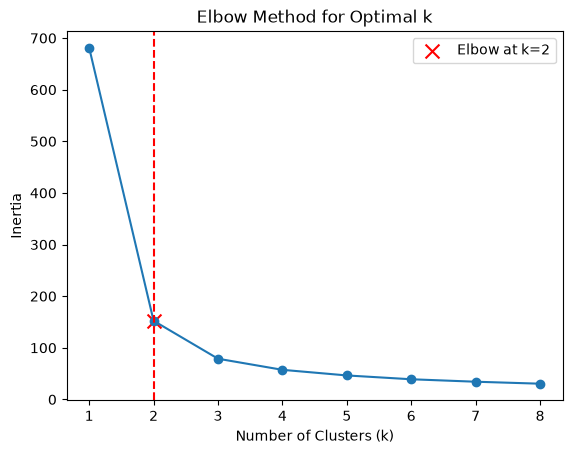

Optimal number of clusters (elbow point): 2


In [16]:
knee = KneeLocator(num_clusters, inertias, curve='convex', direction='decreasing')
elbow_k = knee.knee

# Plot inertias vs num_clusters
plt.plot(num_clusters, inertias, '-o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

# Annotate elbow point
if elbow_k is not None:
    plt.axvline(x=elbow_k, color='red', linestyle='--')
    plt.scatter(elbow_k, inertias[elbow_k-1], c='red', s=100, marker='x', label=f'Elbow at k={elbow_k}')
    plt.legend()
    plt.show()

print(f"Optimal number of clusters (elbow point): {elbow_k}")